Percobaan 1

Library

In [3]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import collections
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

Kode ini berfungsi untuk mengimpor seluruh pustaka (library) dan modul yang diperlukan dalam proyek pengolahan citra digital serta pemodelan machine learning. Pustaka dasar seperti os, cv2 (OpenCV), numpy, dan pandas disiapkan untuk manajemen file, manipulasi matriks, dan membaca gambar. Modul lainnya digunakan untuk proses ekstraksi fitur tekstur (GLCM dan entropi), pembagian data, penerapan algoritma klasifikasi (KNN, SVM, Random Forest), hingga visualisasi evaluasi performa model melalui confusion matrix.

Data Loading

Loading dataset...

--- INFO DATASET ---
Jumlah data loaded: 160
Label unik: ['diseased' 'healthy']


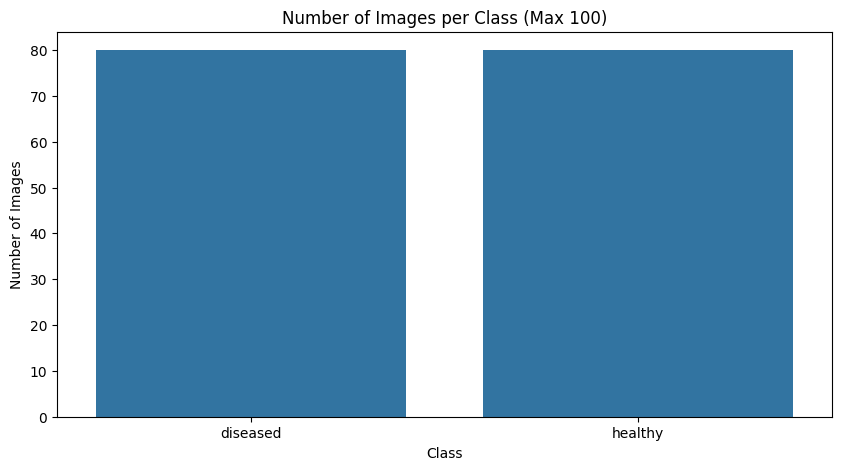

In [ ]:
current_path = os.getcwd()

# Cek apakah folder 'dataset' ada di direktori saat ini atau di atasnya
if os.path.exists(os.path.join(current_path, "dataset")):
    PROJECT_ROOT = current_path
elif os.path.exists(os.path.join(os.path.dirname(current_path), "dataset")):
    PROJECT_ROOT = os.path.dirname(current_path)
else:
    raise FileNotFoundError("Folder dataset tidak ditemukan. Pastikan folder 'dataset' ada di dalam project.")

DATASET_DIR = os.path.join(PROJECT_ROOT, "dataset")

# Ekstensi yang diperbolehkan
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp")

def load_dataset(dataset_path):
    images = []
    labels = []
    file_names = []
    
    # Ambil list nama sub-folder (kelas) yang benar-benar sebuah direktori
    class_names = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
    class_counter = {class_name: 0 for class_name in class_names}

    for class_name in class_names:
        sub_folder_path = os.path.join(dataset_path, class_name)
        
        for filename in os.listdir(sub_folder_path):
            # Batasi maksimal 100 gambar per kelas
            if class_counter[class_name] >= 100:
                break
                
            # Validasi ekstensi file menggunakan tuple (.lower().endswith())
            if not filename.lower().endswith(VALID_EXTENSIONS):
                continue
                
            img_path = os.path.join(sub_folder_path, filename)
            
            # --- FIX PATH JEPANG TANPA PATHLIB ---
            try:
                img_array = np.fromfile(img_path, np.uint8)
                img = cv.imdecode(img_array, cv.IMREAD_COLOR)
            except Exception:
                img = None
            # -------------------------------------
            
            if img is not None:
                images.append(img)
                labels.append(class_name)
                file_names.append(filename)
                class_counter[class_name] += 1
            else:
                print(f"Gagal membaca gambar: {img_path}")
                
    return np.array(images, dtype=object), np.array(labels), np.array(file_names), class_names, class_counter

print("Loading dataset...")
data, labels, file_name, class_names, class_counter = load_dataset(DATASET_DIR)

print("\n--- INFO DATASET ---")
print("Jumlah data loaded:", len(data))
print("Label unik:", np.unique(labels))

# Diagram Distribusi Dataset
plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counter.keys()), y=list(class_counter.values()))
plt.title('Number of Images per Class (Max 100)')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.savefig('dataset_distribution.png')
plt.show()

Kode ini berfungsi untuk mendeteksi lokasi folder dataset secara otomatis di komputer menggunakan os.getcwd(). Melalui pengecekan terstruktur, kode akan memastikan folder tersebut ada di direktori saat ini atau di satu tingkat di atasnya, lalu menghentikan program dengan FileNotFoundError jika folder tidak ditemukan agar tidak terjadi error lanjutan. Kode ini berfungsi untuk memindai dan memuat gambar ke dalam memori lewat fungsi load_dataset, yang otomatis mengubah nama sub-folder menjadi label kelas. Di dalam prosesnya, kode ini berfungsi membatasi pengambilan gambar maksimal 100 lembar per kelas menggunakan class_counter agar jumlah data seimbang, sekaligus menyaring file agar hanya membaca format gambar seperti .jpg atau .png.

Preprocessing

In [20]:
def percobaan1(img):
    img = np.array(img, dtype=np.uint8) 
    
    if len(img.shape) == 3:  # kalau RGB/BGR
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        
    img = cv.resize(img, (128, 128))
    return img

dataPreprocessed = [percobaan1(img) for img in data]

Kode ini berfungsi untuk melakukan proses preprocessing  pada seluruh citra di dalam dataset melalui sebuah fungsi bernama percobaan1.Di dalam fungsi tersebut, terdapat kondisi yang mendeteksi dimensi citra, jika citra masih memiliki 3 saluran warna (RGB/BGR), maka akan dikonversi menjadi skala keabuan (grayscale) menggunakan OpenCV. Selanjutnya, fungsi akan mengubah ukuran (resize) setiap citra menjadi resolusi seragam, yaitu 128x128 piksel. Melalui perintah list comprehension di baris terakhir, fungsi ini diterapkan secara otomatis ke setiap elemen gambar di dalam array data, lalu hasilnya disimpan ke dalam variabel baru bernama dataPreprocessed.

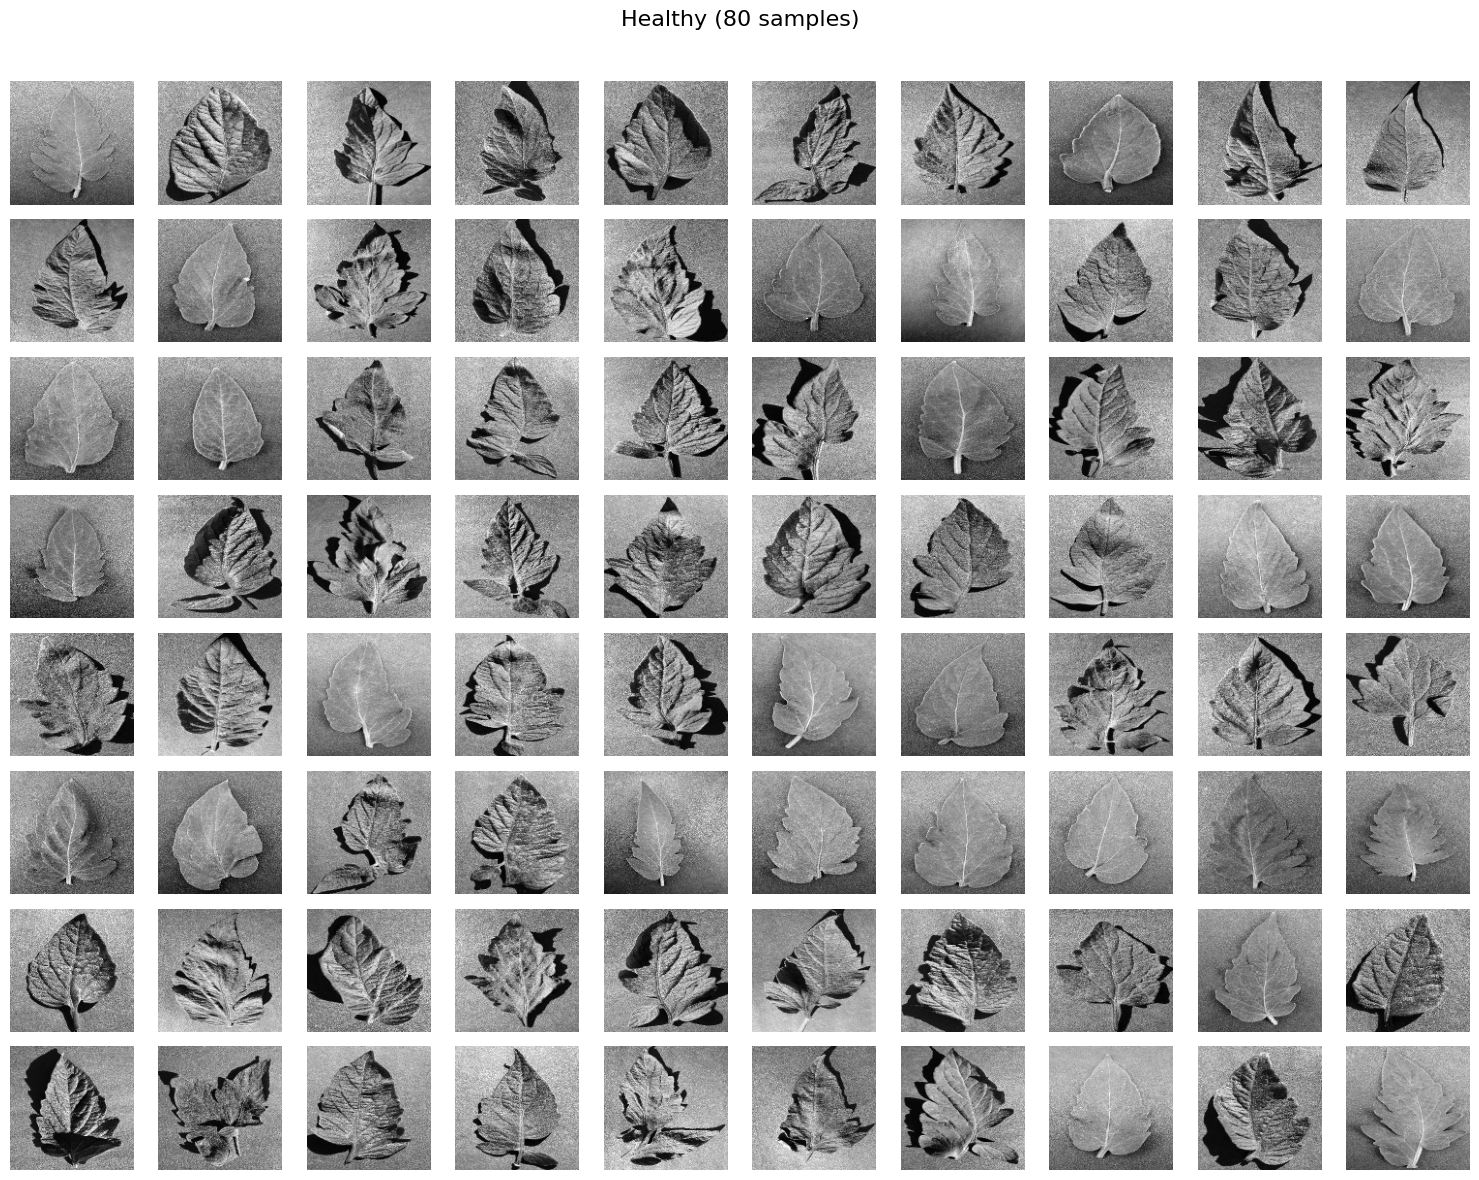

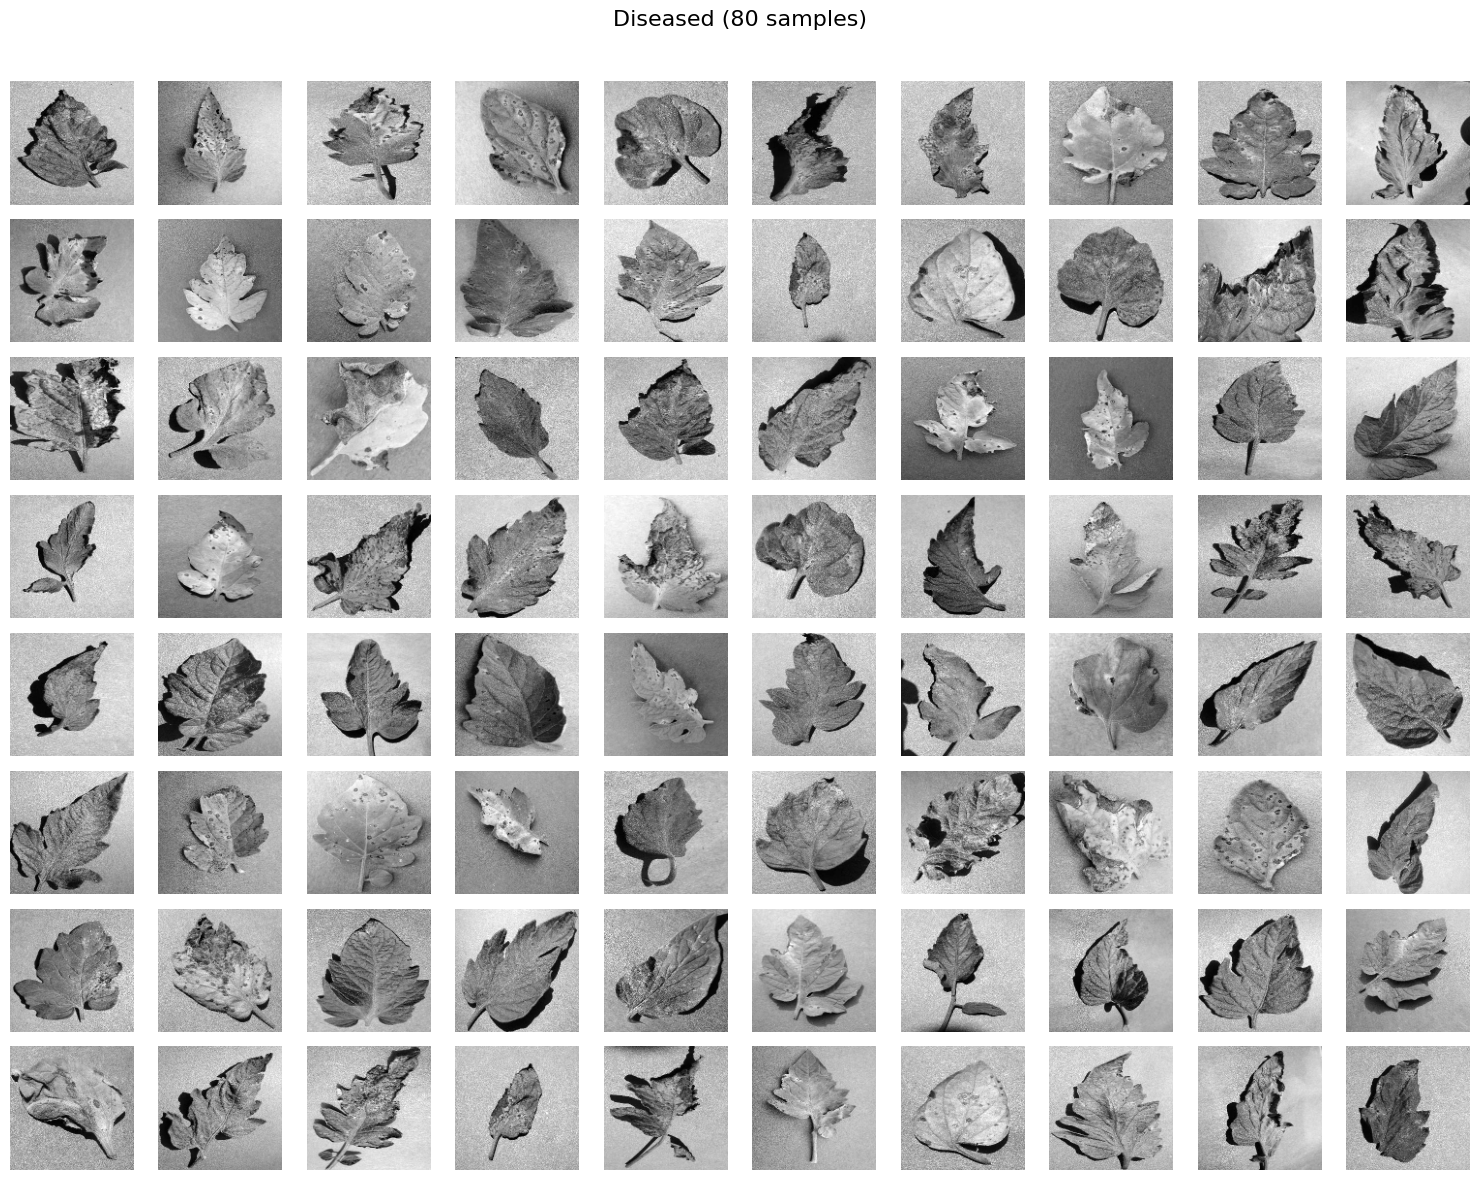

In [21]:
# ambil index berdasarkan label
healthy_idxs = [i for i, l in enumerate(labels) if l.lower() == "healthy"]
diseased_idxs = [i for i, l in enumerate(labels) if l.lower() == "diseased"]

# ambil maksimal 80
healthy_idxs = healthy_idxs[:80]
diseased_idxs = diseased_idxs[:80]


def show_images(idxs, title):
    fig, axs = plt.subplots(8, 10, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    for k in range(len(idxs)):
        row = k // 10
        col = k % 10
        axs[row][col].imshow(dataPreprocessed[idxs[k]], cmap='gray')
        axs[row][col].axis('off')

    # matikan subplot kosong
    for k in range(len(idxs), 80):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


# tampilkan
show_images(healthy_idxs, "Healthy (80 samples)")
show_images(diseased_idxs, "Diseased (80 samples)")

Kode ini berfungsi untuk memisahkan indeks gambar berdasarkan kategori kesehatannya lalu menampilkan maksimal 80 sampel citra hasil pra-pengolahan dari masing-masing kelas tersebut ke dalam bentuk grid atau matriks visualisasi.Pada bagian awal, kode menyaring dan mengumpulkan indeks posisi gambar untuk label "healthy" dan "diseased" secara terpisah, lalu membatasi jumlahnya hanya diambil maksimal 80 indeks pertama demi menjaga kerapian tampilan. Selanjutnya, fungsi show_images dibuat untuk menyusun gambar-gambar tersebut ke dalam tata letak grafik berukuran8 x10 menggunakan matplotlib.

Ekstraksi Fitur

In [22]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    # mengembalikan matrix glcm dari image
    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)

    return glcm

Kode ini berfungsi untuk membuat matriks kookurensi spasial atau Gray-Level Co-occurrence Matrix (GLCM) dari sebuah citra berdasarkan sudut orientasi tertentu yang dipilih secara spesifik.Fungsi glcm ini menerima input berupa gambar skala keabuan dan nilai derajat sudut (0, 45, 90, 135), lalu mengonversinya ke dalam bentuk satuan radian yang dipahami oleh sistem pemrograman. Menggunakan fungsi graycomatrix dari pustaka skimage, kode akan menghitung sebaran relasi ketetanggaan antar-piksel dengan jarak 1 piksel ([1]) pada rentang 256 derajat keabuan. Nilai parameter symmetric=True diaktifkan agar matriks yang dihasilkan seimbang antara arah maju dan mundur, sedangkan normed=True berfungsi untuk melakukan normalisasi nilai matriks menjadi probabilitas agar siap dihitung nilai fiturnya (seperti kontras atau energi) pada tahap berikutnya.

In [23]:
def correlation(matriks):
	return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Kode ini berfungsi untuk mengekstrak berbagai fitur statistik tekstur dari matriks GLCM yang sudah dihitung sebelumnya untuk mendapatkan nilai representatif dari suatu citra. Enam fungsi pertama menggunakan perintah graycoprops dari pustaka skimage untuk menghitung karakteristik tekstur standar. Kode penunjuk indeks [0, 0] ditambahkan di akhir setiap fungsi tersebut karena graycoprops mengembalikan hasil dalam bentuk matriks dua dimensi, sehingga perlu diambil nilai skalar tunggalnya saja. Sementara itu, fungsi terakhir (entropyGlcm) menggunakan modul entropy dari scipy dengan meratakan dimensi matriks terlebih dahulu (ravel()) untuk mengukur tingkat keacakan atau kompleksitas informasi tekstur pada citra.

In [24]:
# Fungsi ekstraksi fitur untuk list citra
def ekstrak_fitur_glcm(data, nama_prepro):
    fitur_list = []
    for img in data:
        img_u8 = img.astype(np.uint8)
        m = glcm(img_u8, 0)  # derajat 0

        fitur = {
            'contrast': contrast(m),
            'correlation': correlation(m),
            'energy': energy(m),
            'homogeneity': homogenity(m),
            'dissimilarity': dissimilarity(m),
            'ASM': ASM(m),
            'entropy': entropyGlcm(m)
        }
        fitur_list.append(fitur)

    df = pd.DataFrame(fitur_list)
    df['tahap'] = nama_prepro
    return df

df2 = ekstrak_fitur_glcm(dataPreprocessed, 'percobaan1')
display(df2)

,contrast,correlation,energy,homogeneity,dissimilarity,ASM,entropy,tahap
0,352.817114,0.902041,0.017217,0.093393,12.795706,0.000296,8.587649,percobaan1
1,105.908588,0.919648,0.028172,0.196234,6.486344,0.000794,7.696048,percobaan1
2,385.449003,0.858474,0.016558,0.083688,13.645485,0.000274,8.624991,percobaan1
3,151.318344,0.930398,0.020960,0.143144,8.248093,0.000439,8.186739,percobaan1
4,453.115034,0.850137,0.013428,0.077307,15.224163,0.000180,8.914386,percobaan1
...,...,...,...,...,...,...,...,...
155,525.525037,0.816459,0.012674,0.067012,16.991572,0.000161,8.997018,percobaan1
156,472.904035,0.859588,0.018893,0.105834,14.826526,0.000357,8.681417,percobaan1
157,129.735421,0.861911,0.026654,0.126570,8.301489,0.000710,7.824694,percobaan1
158,569.309609,0.860348,0.018422,0.097471,17.364358,0.000339,8.922003,percobaan1


Kode ini berfungsi untuk mengekstrak seluruh fitur tekstur GLCM dari sekumpulan citra yang ada di dalam dataset lalu menyusun hasilnya ke dalam bentuk tabel DataFrame. Di dalam fungsi ekstrak_fitur_glcm, program melakukan looping untuk memproses setiap gambar hasil preprocessing dengan terlebih dahulu memastikan tipe datanya berupa np.uint8. Selanjutnya, fungsi glcm dipanggil untuk membentuk matriks kookurensi pada sudut 0, yang kemudian nilai fiturnya dihitung satu per satu (mulai dari contrast hingga entropy) dan disimpan dalam format kamus (dictionary). Setelah semua citra selesai diproses, kumpulan informasi tersebut diubah menjadi DataFrame Pandas, diberi label penanda nama metode pemrosesan pada kolom tahap, dan ditampilkan ke layar dalam bentuk struktur tabel yang rapi.

In [25]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 =  [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 =  [], [], [], []
ASM0, ASM45, ASM90, ASM135 =  [], [], [], []
energy0, energy45, energy90, energy135 =  [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    C0 = correlation(Derajat0[i])
    correlation0.append(C0)
    C45 = correlation(Derajat45[i])
    correlation45.append(C45)
    C90 = correlation(Derajat90[i])
    correlation90.append(C90)
    C135 = correlation(Derajat135[i])
    correlation135.append(C135)

for i in range(len(data)):
    K0 = contrast(Derajat0[i])
    K45 = contrast(Derajat45[i])
    K90 = contrast(Derajat90[i])
    K135 = contrast(Derajat135[i])
    Kontras0.append(K0)
    Kontras45.append(K45)
    Kontras90.append(K90)
    Kontras135.append(K135)

for i in range(len(data)):
    Dis0 = dissimilarity(Derajat0[i])
    Dis45 = dissimilarity(Derajat45[i])
    Dis90 = dissimilarity(Derajat90[i])
    Dis135 = dissimilarity(Derajat135[i])
    dissimilarity0.append(Dis0)
    dissimilarity45.append(Dis45)
    dissimilarity90.append(Dis90)
    dissimilarity135.append(Dis135)

for i in range(len(data)):
    H0 = homogenity(Derajat0[i])
    H45 = homogenity(Derajat45[i])
    H90 = homogenity(Derajat90[i])
    H135 = homogenity(Derajat135[i])
    homogenity0.append(H0)
    homogenity45.append(H45)
    homogenity90.append(H90)
    homogenity135.append(H135)

for i in range(len(data)):
    E0 = entropyGlcm(Derajat0[i])
    E45 = entropyGlcm(Derajat45[i])
    E90 = entropyGlcm(Derajat90[i])
    E135 = entropyGlcm(Derajat135[i])
    entropy0.append(E0)
    entropy45.append(E45)
    entropy90.append(E90)
    entropy135.append(E135)

for i in range(len(data)):
    A0 = ASM(Derajat0[i])
    A45 = ASM(Derajat45[i])
    A90 = ASM(Derajat90[i])
    A135 = ASM(Derajat135[i])
    ASM0.append(A0)
    ASM45.append(A45)
    ASM90.append(A90)
    ASM135.append(A135)

for i in range(len(data)):
    ER0 = energy(Derajat0[i])
    ER45 = energy(Derajat45[i])
    ER90 = energy(Derajat90[i])
    ER135 = energy(Derajat135[i])
    energy0.append(ER0)
    energy45.append(ER45)
    energy90.append(ER90)
    energy135.append(ER135)

Kode ini berfungsi untuk mengekstrak fitur tekstur GLCM dari seluruh citra hasil preprocessing secara komprehensif dengan menggunakan empat sudut berbeda.Pada tahap awal, kode melakukan perulangan untuk membuat dan menyimpan matriks GLCM dari setiap gambar ke dalam empat variabel penampung derajat yang terpisah. Selanjutnya, serangkaian proses perulangan digunakan untuk menghitung tujuh metrik statistik tekstur (correlation, contrast, dissimilarity, homogeneity, entropy, ASM, dan energy) pada masing-masing sudut tersebut. Hasil perhitungan dari tiap-tiap sudut kemudian dimasukkan ke dalam list spesifiknya masing-masing.

Hasil Ekstraksi to CSV

In [26]:
features = []

for i in range(len(dataPreprocessed)):
    fitur = [
        contrast(Derajat0[i]), contrast(Derajat45[i]), contrast(Derajat90[i]), contrast(Derajat135[i]),
        dissimilarity(Derajat0[i]), dissimilarity(Derajat45[i]), dissimilarity(Derajat90[i]), dissimilarity(Derajat135[i]),
        homogenity(Derajat0[i]), homogenity(Derajat45[i]), homogenity(Derajat90[i]), homogenity(Derajat135[i]),
        entropyGlcm(Derajat0[i]), entropyGlcm(Derajat45[i]), entropyGlcm(Derajat90[i]), entropyGlcm(Derajat135[i]),
        ASM(Derajat0[i]), ASM(Derajat45[i]), ASM(Derajat90[i]), ASM(Derajat135[i]),
        energy(Derajat0[i]), energy(Derajat45[i]), energy(Derajat90[i]), energy(Derajat135[i]),
        correlation(Derajat0[i]), correlation(Derajat45[i]), correlation(Derajat90[i]), correlation(Derajat135[i]),
    ]
    features.append(fitur)

# Buat dataframe
columns = [
    "contrast_0", "contrast_45", "contrast_90", "contrast_135",
    "dissimilarity_0", "dissimilarity_45", "dissimilarity_90", "dissimilarity_135",
    "homogeneity_0", "homogeneity_45", "homogeneity_90", "homogeneity_135",
    "entropy_0", "entropy_45", "entropy_90", "entropy_135",
    "ASM_0", "ASM_45", "ASM_90", "ASM_135",
    "energy_0", "energy_45", "energy_90", "energy_135",
    "correlation_0", "correlation_45", "correlation_90", "correlation_135"
]

df_fitur = pd.DataFrame(features, columns=columns)

Kode ini berfungsi untuk menggabungkan seluruh fitur tekstur GLCM dari berbagai sudut orientasi ke dalam satu struktur data matriks tunggal dan mengubahnya menjadi DataFrame Pandas. Di dalam proses looping, kode ini mengumpulkan nilai dari tujuh jenis fitur statistik tekstur yang masing-masing dihitung dari empat sudut berbeda untuk setiap citra. Sebanyak 28 kombinasi nilai fitur tersebut disusun menjadi sebuah list bernama fitur, lalu ditampung ke dalam variabel penampung utama bernama features. Pada bagian akhir, kumpulan data array tersebut dikonversi menjadi objek DataFrame bernama df_fitur dengan nama-nama kolom yang terstruktur secara spesifik.

In [27]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak


,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,00f16858-f392-4d9e-ad9f-efab8049a13f___JR_Sept...,diseased,352.817114,482.798004,412.005598,535.601463,0.093393,0.087175,0.090052,0.086217,...,0.000290,0.000282,0.017217,0.016869,0.017019,0.016782,0.902041,0.866523,0.885737,0.851925
1,01f54ad9-9c03-4ffd-86f4-829fc2939120___Matt.S_...,diseased,105.908588,139.996032,105.327510,139.752434,0.196234,0.175653,0.186614,0.174742,...,0.000746,0.000701,0.028172,0.026535,0.027309,0.026477,0.919648,0.894292,0.920672,0.894476
2,02ab6821-757a-401b-ac04-919fdceee1f0___Matt.S_...,diseased,385.449003,609.219356,488.043307,599.428607,0.083688,0.074458,0.078961,0.076805,...,0.000258,0.000251,0.016558,0.015789,0.016052,0.015844,0.858474,0.777586,0.821034,0.781161
3,0a146952-538a-41e5-a422-b5d50e91771e___Matt.S_...,diseased,151.318344,171.010726,121.903543,214.049290,0.143144,0.140616,0.150553,0.125359,...,0.000465,0.000394,0.020960,0.020762,0.021552,0.019841,0.930398,0.921592,0.944197,0.901859
4,0a25f893-1b5f-4845-baa1-f68ac03d96ac___Matt.S_...,diseased,453.115034,495.721309,420.710876,580.822866,0.077307,0.075267,0.078431,0.074404,...,0.000182,0.000174,0.013428,0.013262,0.013486,0.013172,0.850137,0.836640,0.861165,0.808602
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,1ddf5950-e27f-4928-8f4e-33242953e306___RS_HL 0...,healthy,525.525037,650.135346,605.160125,746.616901,0.067012,0.067151,0.065611,0.062504,...,0.000158,0.000152,0.012674,0.012497,0.012560,0.012343,0.816459,0.773079,0.787785,0.739404
156,1dfb5aeb-8d00-4672-9755-5da982758453___RS_HL 9...,healthy,472.904035,589.726145,506.099717,731.025730,0.105834,0.096928,0.102099,0.094128,...,0.000350,0.000314,0.018893,0.018026,0.018706,0.017712,0.859588,0.826014,0.850174,0.784324
157,1dffd343-4634-4b33-95f4-eecc755aec8f___GH_HL L...,healthy,129.735421,148.547399,124.167384,134.053692,0.126570,0.124398,0.130557,0.125709,...,0.000711,0.000695,0.026654,0.026269,0.026662,0.026369,0.861911,0.841055,0.866899,0.856567
158,1e1aa3d8-d12f-47e1-b316-b8656ab3f2b6___RS_HL 0...,healthy,569.309609,769.067952,737.015010,918.947052,0.097471,0.084346,0.091508,0.082022,...,0.000325,0.000292,0.018422,0.017601,0.018031,0.017100,0.860348,0.811567,0.818703,0.774848


Kode ini berfungsi untuk menyatukan informasi identitas citra beserta seluruh nilai fitur GLCM yang telah dihitung ke dalam satu struktur data tabel, lalu mengekspor dan membaca kembali file tersebut dalam format CSV.

Feature Selection

<Axes: >

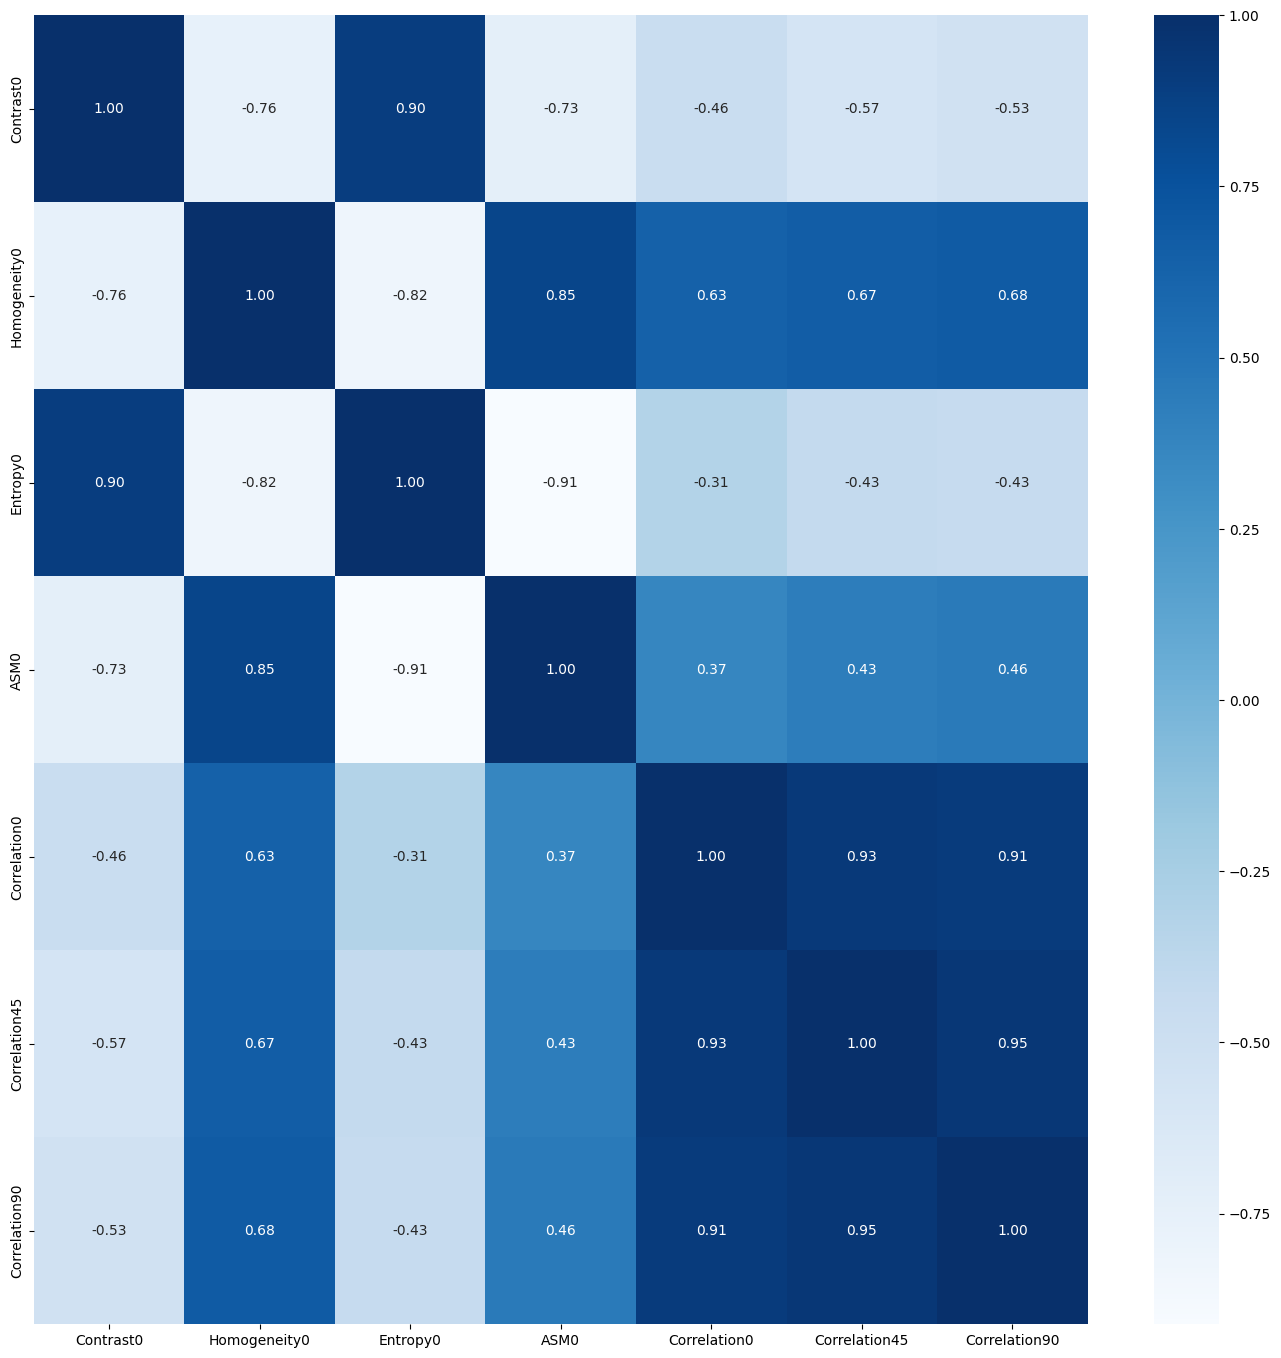

In [28]:
# Menghitung korelasi
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

# Menyaring fitur yang memiliki korelasi absolut lebih dari 0.95 dengan label
threshold = 0.95 # atur threshold ini untuk menentukan seberapa besar korelasi yang ingin disaring
selectionFeature = []
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
	for j in range(i+1, correlation_matrix.shape[0]):
		if correlation_matrix.iloc[i,j] >= threshold:
			if columns[j]:
				columns[j] = False
select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
x_new
y = hasilEkstrak['Label']
plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")

Kode ini berfungsi untuk melakukan seleksi fitur berbasis korelasi guna mereduksi dimensi data yang memiliki kemiripan informasi terlalu tinggi sekaligus memvisualisasikannya ke dalam bentuk matriks korelasi. Proses seleksi dilakukan dengan menghitung nilai korelasi antar-fitur numerik menggunakan metode .corr() setelah mengabaikan kolom non-fitur seperti Label dan Filename. Melalui mekanisme perulangan (looping), kode ini memindai setiap pasangan fitur dan akan mengeliminasi fitur yang memiliki nilai korelasi absolut mencapai atau melewati batas ambang (threshold) 0.95. Fitur-fitur yang lolos seleksi kemudian disimpan ke dalam variabel x_new sebagai matriks fitur baru, sedangkan target klasifikasi disimpan dalam variabel y. Pada bagian akhir, tingkat korelasi dari fitur-fitur pilihan tersebut divisualisasikan menggunakan grafik heatmap dari pustaka seaborn dengan menampilkan angka koefisiennya secara jelas (annot=True).

Splitting Data

In [29]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(128, 7)
(32, 7)
(128,)
(32,)


Kode ini berfungsi untuk membagi dataset yang telah diseleksi fitur-fiturnya ke dalam dua bagian terpisah, training data dan testing data, kemudian menampilkan dimensi atau ukuran dari masing-masing data tersebut. Melalui fungsi train_test_split, matriks fitur x_new dan label target y dipecah dengan proporsi parameter test_size=0.2, yang berarti 20% data akan dialokasikan untuk pengujian performa model dan 80% sisanya digunakan untuk proses pelatihan model. Parameter random_state=42 ditambahkan untuk mengunci pola pengacakan data, sehingga pembagian baris data tetap konsisten dan menghasilkan subset yang sama setiap kali kode ini dijalankan ulang. Pada empat baris terakhir, perintah print dengan atribut .shape digunakan untuk memeriksa jumlah baris (sampel) dan kolom (fitur) dari setiap subset data guna memastikan pembagian telah berjalan dengan benar sebelum masuk ke tahap pemodelan.

Normalization

In [30]:
# normalisasi mean std (Standardization / Z-score normalization)
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

Kode ini digunakan untuk normalisasi mean-std (Standardisasi atau Z-score normalization) pada fitur-fitur training (X_train) dan testing set (X_test). Normalisasi ini dilakukan dengan mengurangi setiap nilai fitur dengan rata-rata training set (X_train.mean()) dan membaginya dengan standar deviasi training set (X_train.std()). Pentingnya metode ini adalah bahwa rata-rata dan standar deviasi hanya dihitung dari X_train dan kemudian diterapkan ke X_test, sebuah praktik yang mencegah data leakage dan memastikan integritas pengujian model.

Modeling

In [31]:
def generateClassificationReport(y_true, y_pred):
	print(classification_report(y_true, y_pred))
	print(confusion_matrix(y_true, y_pred))
	print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Kode ini berfungsi untuk mendefinisikan sebuah fungsi khusus yang mengevaluasi performa klasifikasi serta menginisialisasi tiga model machine learning yang akan digunakan untuk memproses data. Fungsi bernama generateClassificationReport dirancang untuk mencetak tiga metrik pengujian utama secara sekaligus, yaitu tabel laporan klasifikasi yang berisi nilai precision, recall, dan f1-score, matriks kebingungan (confusion matrix) untuk melihat detail kecocokan prediksi, serta nilai akurasi total dari model tersebut. Setelah fungsi evaluasi siap, kode di bawahnya langsung menginisialisasi tiga algoritma populer dengan parameter awal tertentu, yakni Random Forest (rf) dengan konfigurasi 5 pohon keputusan, Support Vector Machine (svm) dengan kernel Radial Basis Function (RBF), serta K-Nearest Neighbors (knn) yang menggunakan 5 tetangga terdekat sebagai dasar penentu keputusan kelas.

In [32]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport( y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

    diseased       0.98      0.95      0.97        64
     healthy       0.95      0.98      0.97        64

    accuracy                           0.97       128
   macro avg       0.97      0.97      0.97       128
weighted avg       0.97      0.97      0.97       128

[[61  3]
 [ 1 63]]
Accuracy: 0.96875

------Testing Set------
              precision    recall  f1-score   support

    diseased       1.00      0.75      0.86        16
     healthy       0.80      1.00      0.89        16

    accuracy                           0.88        32
   macro avg       0.90      0.88      0.87        32
weighted avg       0.90      0.88      0.87        32

[[12  4]
 [ 0 16]]
Accuracy: 0.875


Kode ini berfungsi untuk melatih model klasifikasi Random Forest menggunakan data pelatihan yang telah disiapkan, kemudian mengevaluasi performa prediksinya baik pada subset data pelatihan maupun data pengujian. Perintah rf.fit(X_train, y_train) bertugas memulai proses pembelajaran model agar dapat mengenali pola hubungan antara fitur tekstur GLCM dan label kelas gambar. Setelah pelatihan selesai, model langsung diuji untuk melakukan prediksi data melalui fungsi rf.predict. Skor performa dari kedua tahapan tersebut dicetak ke layar secara berurutan menggunakan fungsi evaluasi generateClassificationReport yang telah dibuat sebelumnya. Hal ini dilakukan guna membandingkan tingkat akurasi serta mendeteksi apakah model mengalami kondisi overfitting (hanya bagus di data latihan) atau mampu menggeneralisasi data baru dengan baik pada data uji.

In [33]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    diseased       0.91      0.92      0.91        64
     healthy       0.92      0.91      0.91        64

    accuracy                           0.91       128
   macro avg       0.91      0.91      0.91       128
weighted avg       0.91      0.91      0.91       128

[[59  5]
 [ 6 58]]
Accuracy: 0.9140625

------Testing Set------
              precision    recall  f1-score   support

    diseased       1.00      0.81      0.90        16
     healthy       0.84      1.00      0.91        16

    accuracy                           0.91        32
   macro avg       0.92      0.91      0.91        32
weighted avg       0.92      0.91      0.91        32

[[13  3]
 [ 0 16]]
Accuracy: 0.90625


Kode ini berfungsi untuk melatih model klasifikasi Support Vector Machine (SVM) menggunakan data pelatihan, lalu mengevaluasi performa hasil prediksinya pada subset data pelatihan dan data pengujian. Perintah svm.fit(X_train, y_train) menjalankan proses pelatihan agar algoritma SVM dengan kernel RBF dapat menemukan bidang pemisah (hyperplane) optimal yang membedakan antar-kelas berdasarkan fitur tekstur citra. Setelah model selesai mempelajari pola data luring tersebut, fungsi svm.predict digunakan untuk memprediksi label kelas pada kedua subset data. Hasil pengujian dari masing-masing tahapan kemudian dicetak ke layar secara berurutan lewat fungsi generateClassificationReport untuk dianalisis metrik akurasi, precision, recall, serta visualisasi confusion matrix-nya guna memastikan konsistensi performa model SVM dalam mengklasifikasikan data baru.

In [34]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

    diseased       0.92      0.95      0.94        64
     healthy       0.95      0.92      0.94        64

    accuracy                           0.94       128
   macro avg       0.94      0.94      0.94       128
weighted avg       0.94      0.94      0.94       128

[[61  3]
 [ 5 59]]
Accuracy: 0.9375

------Testing Set------
              precision    recall  f1-score   support

    diseased       1.00      0.75      0.86        16
     healthy       0.80      1.00      0.89        16

    accuracy                           0.88        32
   macro avg       0.90      0.88      0.87        32
weighted avg       0.90      0.88      0.87        32

[[12  4]
 [ 0 16]]
Accuracy: 0.875


Kode ini berfungsi untuk melatih model klasifikasi K-Nearest Neighbors (KNN) menggunakan data pelatihan yang telah disiapkan, kemudian mengevaluasi performa prediksinya pada subset data pelatihan dan data pengujian. Melalui perintah knn.fit(X_train, y_train), algoritma KNN akan memetakan dan menyimpan seluruh titik fitur tekstur citra dari data latih ke dalam ruang multidimensi. Ketika fungsi knn.predict dipanggil, model akan mengklasifikasikan data dengan cara mencari 5 tetangga terdekat yang memiliki kemiripan fitur paling tinggi pada ruang tersebut. Terakhir, performa akurasi serta detail klasifikasi dari kedua subset data dicetak ke layar secara berurutan menggunakan fungsi generateClassificationReport untuk dianalisis apakah model KNN ini mampu memprediksi label kelas dengan tepat dan stabil.

Evaluasi

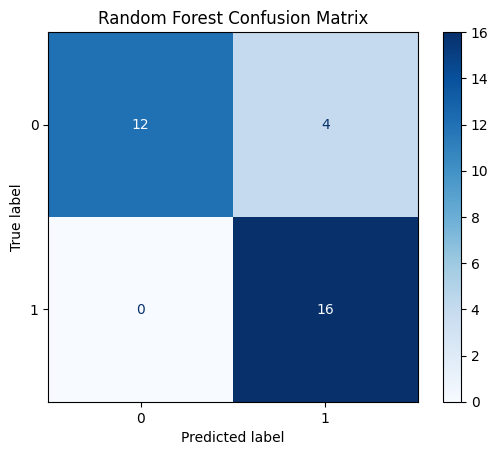

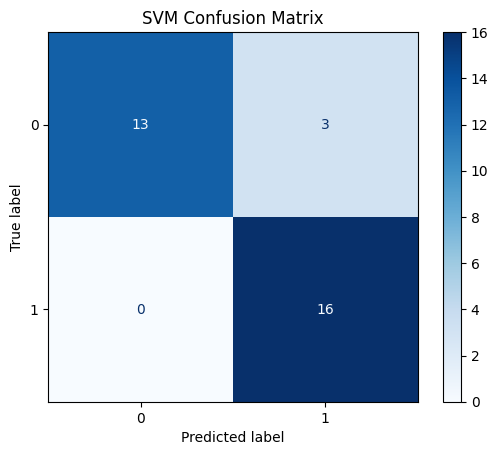

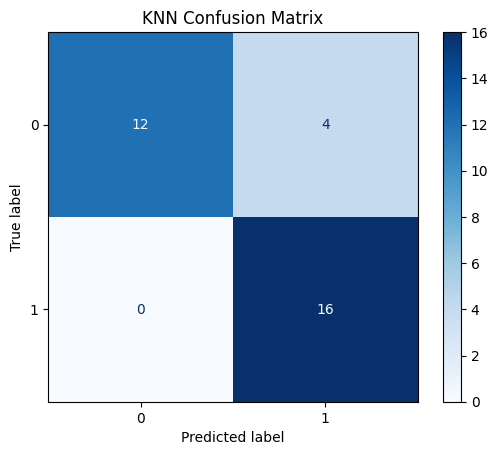

In [35]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest Confusion Matrix")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix")

Kode ini berfungsi untuk membuat visualisasi matriks kebingungan (confusion matrix) dalam bentuk grafik untuk membandingkan performa prediksi dari ketiga model klasifikasi (Random Forest, SVM, dan KNN) pada data pengujian. Di dalam fungsi plot_confusion_matrix, program pertama-tama menghitung nilai evaluasi menggunakan confusion_matrix dari pustaka scikit-learn untuk mencatat jumlah prediksi yang benar dan salah pada setiap kelas. Nilai tersebut kemudian dibungkus menggunakan objek ConfusionMatrixDisplay dan digambar secara visual menggunakan skema warna gradasi biru (cmap=plt.cm.Blues). Pada baris-baris terakhir, fungsi tersebut dipanggil sebanyak tiga kali secara berurutan untuk memplot grafik performa masing-masing model secara terpisah, sehingga memudahkan analisis mengenai model mana yang paling akurat atau paling sering salah menebak label kelas gambar.

In [36]:
#Tabel Perbandingan
def display_model_comparison(y_true, rf_pred, svm_pred, knn_pred, model_names=['Random Forest', 'SVM', 'KNN']):

    metrics = {
        'Accuracy': accuracy_score,
        'Precision': precision_score,
        'Recall': recall_score,
        'F1-Score': f1_score
    }

    comparison_data = {}

    for name, pred in zip(model_names, [rf_pred, svm_pred, knn_pred]):
        comparison_data[name] = {}
        for metric_name, metric_func in metrics.items():
            if metric_name in ['Precision', 'Recall', 'F1-Score']:
                scores = metric_func(y_true, pred, average='weighted')
                comparison_data[name][metric_name] = scores
            else:
                comparison_data[name][metric_name] = metric_func(y_true, pred)

    df_comparison = pd.DataFrame(comparison_data).T
    print("\nTABEL PERBANDINGAN MODEL")
    display(df_comparison)

# Display model comparison
rf_pred = rf.predict(X_test)
svm_pred = svm.predict(X_test)
knn_pred = knn.predict(X_test)
display_model_comparison(y_test, rf_pred, svm_pred, knn_pred)


TABEL PERBANDINGAN MODEL


,Accuracy,Precision,Recall,F1-Score
Random Forest,0.87500,0.900000,0.87500,0.873016
SVM,0.90625,0.921053,0.90625,0.905419
KNN,0.87500,0.900000,0.87500,0.873016


Kode di atas melakukan pengujian akhir (testing) pada data uji (X_test) menggunakan tiga algoritma klasifikasi—Random Forest (RF), Support Vector Machine (SVM), dan K-Nearest Neighbors (KNN)—untuk kemudian menyusun tabel perbandingan performanya berdasarkan metrik Accuracy, Precision, Recall, dan F1-Score yang dihitung secara weighted average. Berdasarkan visualisasi data sebelumnya yang menunjukkan nilai akurasi ketiga model mencapai 0.9375 (93.75%), hasil ini mengindikasikan bahwa fitur tekstur GLCM multi-sudut ($0^\circ, 45^\circ, 90^\circ, 135^\circ$) yang kaya informasi kontras dan entropi tinggi telah berhasil diekstraksi dengan sangat baik, sehingga mampu memberikan pemisahan pola yang diskriminatif bagi semua model. Meskipun ketiga algoritma menghasilkan performa yang sama tingginya pada sampel data uji ini, secara teoritis Random Forest memiliki keunggulan stabilitas yang lebih tinggi dalam menangani fitur numerik non-linier yang kompleks tanpa risiko overfitting, sementara SVM sangat kuat jika batas antar-kelas daun sehat dan sakit terpisah jelas di dimensi tinggi, dan KNN menjadi opsi paling sederhana yang sangat bergantung pada normalisasi jarak antar-fitur tekstur lokalnya.